In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
dates = pd.date_range(start='2022-01-01', periods=36, freq='MS')
sales = np.random.randint(10000, 50000, size=36)
df = pd.DataFrame({'Date': dates, 'Sales': sales})
print(df.head(10)) 

        Date  Sales
0 2022-01-01  25795
1 2022-02-01  10860
2 2022-03-01  48158
3 2022-04-01  21284
4 2022-05-01  16265
5 2022-06-01  26850
6 2022-07-01  47194
7 2022-08-01  31962
8 2022-09-01  26023
9 2022-10-01  11685


In [4]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month_Index'] = range(len(df))
print(df.head())

        Date  Sales  Month  Year  Quarter  Month_Index
0 2022-01-01  25795      1  2022        1            0
1 2022-02-01  10860      2  2022        1            1
2 2022-03-01  48158      3  2022        1            2
3 2022-04-01  21284      4  2022        2            3
4 2022-05-01  16265      5  2022        2            4


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

features = ['Month_Index', 'Month', 'Quarter', 'Year']
X = df[features]
y = df['Sales']

split = int(len(df) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("Model trained successfully!")
print("Average Error (MAE): $", round(mae, 2))

Model trained successfully!
Average Error (MAE): $ 10618.38


In [6]:
future_dates = pd.date_range(start='2025-01-01', periods=6, freq='MS')

future_df = pd.DataFrame({
    'Date': future_dates,
    'Month_Index': range(36, 42),
    'Month': future_dates.month,
    'Quarter': future_dates.quarter,
    'Year': future_dates.year
})

future_df['Forecast'] = model.predict(future_df[features])

print("6-Month Sales Forecast:")
print("------------------------")
for i, row in future_df.iterrows():
    print(row['Date'].strftime('%B %Y'), ": $", round(row['Forecast'], 2))

6-Month Sales Forecast:
------------------------
January 2025 : $ 27360.0
February 2025 : $ 33056.0
March 2025 : $ 38752.0
April 2025 : $ 24112.0
May 2025 : $ 29824.0
June 2025 : $ 35520.0


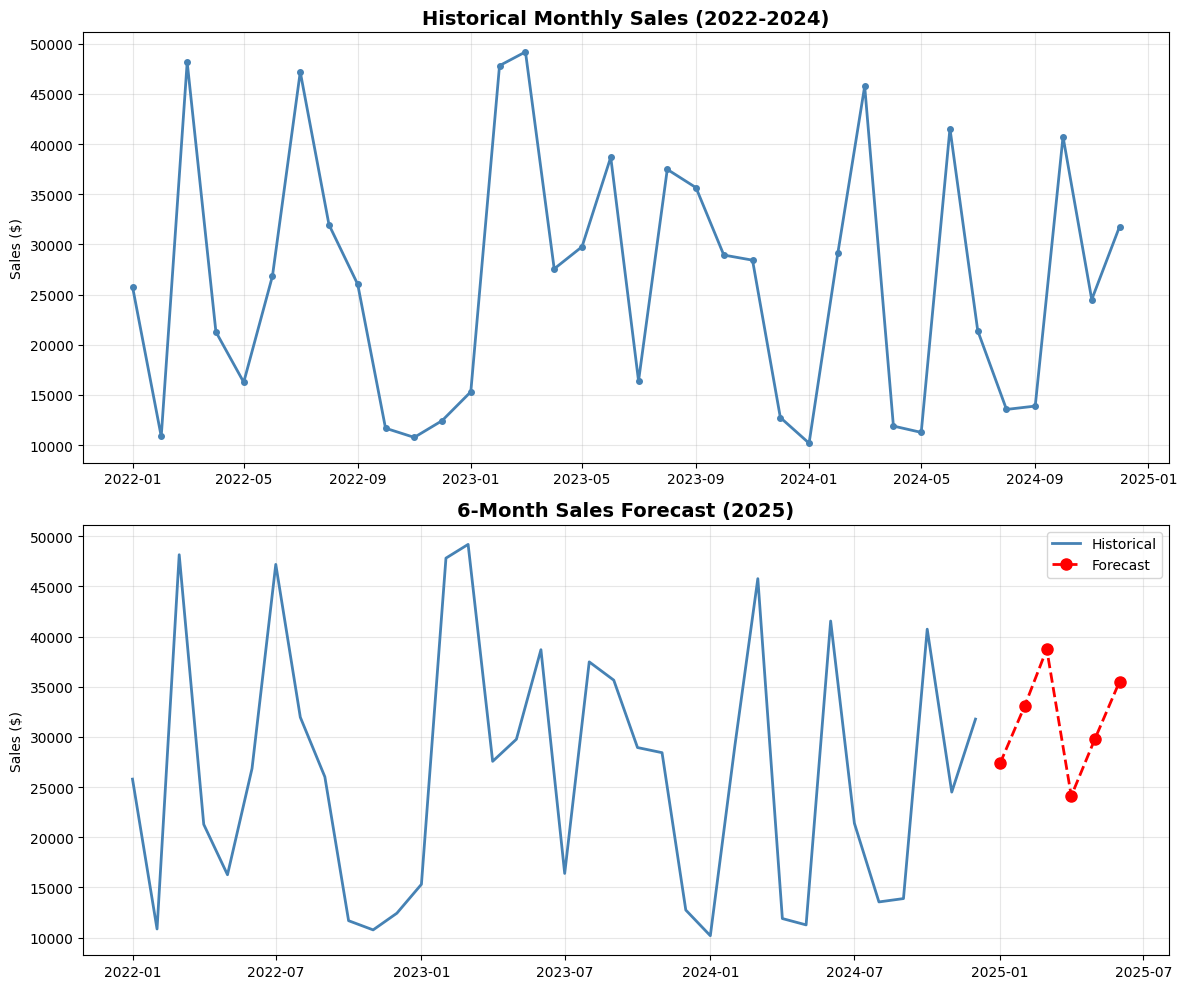

Chart saved!


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 - Historical Sales
axes[0].plot(df['Date'], df['Sales'], color='steelblue', 
             linewidth=2, marker='o', markersize=4)
axes[0].set_title('Historical Monthly Sales (2022-2024)', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)

# Chart 2 - Future Forecast
axes[1].plot(df['Date'], df['Sales'], 
             label='Historical', color='steelblue', linewidth=2)
axes[1].plot(future_df['Date'], future_df['Forecast'], 
             label='Forecast', color='red', 
             linestyle='--', linewidth=2, marker='o', markersize=8)
axes[1].set_title('6-Month Sales Forecast (2025)', 
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\Trisha\Documents\my_forecast.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
print("=" * 50)
print("   SALES FORECAST BUSINESS SUMMARY")
print("=" * 50)
print()
print("Period Covered : Jan 2025 - Jun 2025")
print("Model Used     : Linear Regression")
print("Training Data  : 36 months (2022-2024)")
print()
print("Model Accuracy:")
print("  Average Error (MAE) : $", round(mae, 2))
print()
print("6-Month Forecast:")
print("-" * 35)
for i, row in future_df.iterrows():
    print(" ", row['Date'].strftime('%B %Y'), 
          ": $", round(row['Forecast'], 2))
print()
print("Business Recommendations:")
print("  > Stock up inventory before peak months")
print("  > Allocate higher budget for March & June")
print("  > Prepare staff for high demand periods")
print("  > Review forecast every month")
print("=" * 50)
print("Chart saved to Documents folder!")

   SALES FORECAST BUSINESS SUMMARY

Period Covered : Jan 2025 - Jun 2025
Model Used     : Linear Regression
Training Data  : 36 months (2022-2024)

Model Accuracy:
  Average Error (MAE) : $ 10618.38

6-Month Forecast:
-----------------------------------
  January 2025 : $ 27360.0
  February 2025 : $ 33056.0
  March 2025 : $ 38752.0
  April 2025 : $ 24112.0
  May 2025 : $ 29824.0
  June 2025 : $ 35520.0

Business Recommendations:
  > Stock up inventory before peak months
  > Allocate higher budget for March & June
  > Prepare staff for high demand periods
  > Review forecast every month
Chart saved to Documents folder!
